# KU Finder — Jina CLIP v2 분실물 Retrieval 실습

이 노트북은 **Google Colab + T4 GPU** 기준입니다.

목표:
1. 사진 ↔ 사진 유사도 비교
2. 글 ↔ 사진 유사도 비교
3. 여러 후보 중 Top-K 검색
4. 사진 + 글 점수 결합
5. embedding 저장/불러오기

> **주의:** cosine similarity 값은 확률(%)이 아닙니다.
> 예: `0.82`가 나와도 "82% 확률로 같은 물건"이라는 뜻은 아닙니다.

---

## 사용 순서

1. Colab에서 이 파일을 엽니다.
2. `런타임 → 런타임 유형 변경 → T4 GPU`
3. STEP 1 실행
4. STEP 2 패키지 설치
5. 설치 후 `런타임 → 세션 다시 시작`
6. STEP 3부터 아래로 순서대로 실행

## STEP 1. GPU 확인

In [ ]:
!nvidia-smi

import torch

print("\nPyTorch version:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU가 잡히지 않았습니다.")
    print("런타임 → 런타임 유형 변경 → T4 GPU를 선택하세요.")

Tue Aug 25 11:42:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## STEP 2. 패키지 설치

Colab 기본 환경에서 `gradio`와 `huggingface-hub` 버전 충돌이 날 수 있어
이번 실습에 필요하지 않은 gradio를 제거합니다.

Jina CLIP v2 실습 안정성을 위해 Transformers는 `4.51.3`으로 고정합니다.

**이 셀 실행 후 반드시 런타임을 한 번 재시작하세요.**

In [ ]:
%pip uninstall -y gradio gradio_client
%pip install -q "transformers==4.51.3" "huggingface-hub<1.0" einops timm pillow accelerate matplotlib

Found existing installation: gradio 6.24.0
Uninstalling gradio-6.24.0:
  Successfully uninstalled gradio-6.24.0
Found existing installation: gradio_client 2.6.0
Uninstalling gradio_client-2.6.0:
  Successfully uninstalled gradio_client-2.6.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.1 MB/s eta 0:00:00


### ⚠️ 여기서 런타임 재시작

Colab 상단:

**런타임 → 세션 다시 시작**

을 누른 뒤 STEP 3부터 실행하세요.

## STEP 3. 설치 버전과 GPU 재확인

In [ ]:
import torch
import transformers
import huggingface_hub
import numpy as np

print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("torch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

transformers: 4.51.3
huggingface_hub: 0.36.2
torch: 2.11.0+cu128
CUDA 사용 가능: True
GPU: Tesla T4


정상 예시:

```text
transformers: 4.51.3
CUDA 사용 가능: True
GPU: Tesla T4
```

## STEP 4. Jina CLIP v2 로딩

In [ ]:
import torch
from transformers import AutoModel

MODEL_NAME = "jinaai/jina-clip-v2"
EMBED_DIM = 512

model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

print("✅ 모델 로딩 완료")
print("device:", next(model.parameters()).device)
print("dtype:", next(model.parameters()).dtype)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_clip.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-clip-implementation:
- configuration_clip.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_clip.py: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- stochastic_depth.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- block.py
- stochastic_depth.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- modeling_xlm_roberta.py
- embedding.py
- rotary.py
- mlp.py
- mha.py
- xlm_padding.py
- block.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following fi

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

✅ 모델 로딩 완료
device: cuda:0
dtype: torch.float16


처음에는 모델 파일 다운로드 때문에 시간이 조금 걸릴 수 있습니다.

우리는 모델을 새로 학습하는 것이 아니라 **embedding 추출용 inference**로 사용합니다.

## STEP 5. 테스트 이미지 업로드

In [ ]:
from google.colab import files

print("테스트 이미지 2장 이상을 업로드하세요.")
print("추천: 같은 물건의 다른 각도 사진 2장 + 전혀 다른 물건 사진 1장")

uploaded = files.upload()

테스트 이미지 2장 이상을 업로드하세요.
추천: 같은 물건의 다른 각도 사진 2장 + 전혀 다른 물건 사진 1장


Saving KakaoTalk_20260825_203549473.jpg to KakaoTalk_20260825_203549473.jpg
Saving KakaoTalk_20260825_203549473_01.jpg to KakaoTalk_20260825_203549473_01.jpg


## STEP 6. 업로드한 이미지 목록 확인

In [ ]:
from pathlib import Path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

image_paths = sorted([
    str(p) for p in Path(".").iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
])

print("이미지 목록:")
for i, path in enumerate(image_paths):
    print(f"[{i}] {path}")

if len(image_paths) < 2:
    print("\n⚠️ 이미지가 2장 이상 필요합니다.")

이미지 목록:
[0] KakaoTalk_20260825_203549473.jpg
[1] KakaoTalk_20260825_203549473_01.jpg


## STEP 7. 업로드 이미지 미리보기

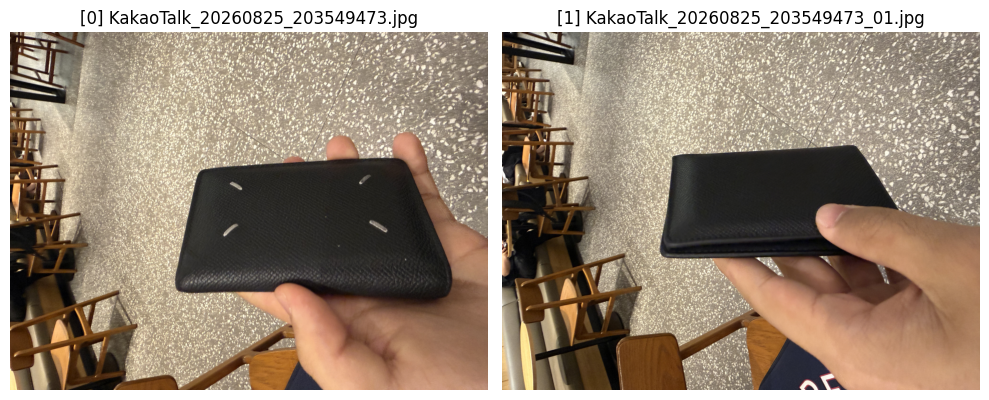

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import math

if len(image_paths) > 0:
    cols = min(3, len(image_paths))
    rows = math.ceil(len(image_paths) / cols)

    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, path in enumerate(image_paths):
        img = Image.open(path).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"[{i}] {path}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## STEP 8. 사진 → Embedding

각 사진을 512차원 숫자 벡터로 바꿉니다.

`normalize_embeddings=True`로 정규화하면,
이후 벡터 내적(dot product)이 cosine similarity와 같아집니다.

In [ ]:
if len(image_paths) == 0:
    raise ValueError("먼저 STEP 5에서 이미지를 업로드하세요.")

image_embeddings = model.encode_image(
    image_paths,
    batch_size=4,
    normalize_embeddings=True,
    truncate_dim=EMBED_DIM
)

image_embeddings = np.asarray(image_embeddings, dtype=np.float32)

print("embedding shape:", image_embeddings.shape)
print("\n첫 번째 이미지 embedding 앞 10개 값:")
print(image_embeddings[0][:10])

preprocessor_config.json:   0%|          | 0.00/584 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


processing_clip.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-clip-implementation:
- processing_clip.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


embedding shape: (2, 512)

첫 번째 이미지 embedding 앞 10개 값:
[ 0.0164032   0.01960754 -0.00157833  0.04638672  0.01956177  0.06262207
 -0.05996704  0.02320862 -0.02705383  0.10455322]


예를 들어 이미지가 3장이면:

```text
(3, 512)
```

즉:
- 이미지 3장
- 이미지 한 장당 숫자 512개

## STEP 9. 사진 ↔ 사진 전체 유사도

In [ ]:
similarity_matrix = image_embeddings @ image_embeddings.T

print("사진 ↔ 사진 cosine similarity\n")

for i, path_i in enumerate(image_paths):
    for j, path_j in enumerate(image_paths):
        print(
            f"[{i}] {path_i}  ↔  [{j}] {path_j}"
            f" : {similarity_matrix[i, j]:.4f}"
        )
    print()

사진 ↔ 사진 cosine similarity

[0] KakaoTalk_20260825_203549473.jpg  ↔  [0] KakaoTalk_20260825_203549473.jpg : 1.0000
[0] KakaoTalk_20260825_203549473.jpg  ↔  [1] KakaoTalk_20260825_203549473_01.jpg : 0.9365

[1] KakaoTalk_20260825_203549473_01.jpg  ↔  [0] KakaoTalk_20260825_203549473.jpg : 0.9365
[1] KakaoTalk_20260825_203549473_01.jpg  ↔  [1] KakaoTalk_20260825_203549473_01.jpg : 0.9998



같은 사진을 자기 자신과 비교하면 거의 `1.0`이 나오는 게 정상입니다.
중요한 건 서로 다른 사진 사이의 점수입니다.

## STEP 10. 사진으로 Top-K 검색 함수

In [ ]:
def search_by_image(
    query_image_path,
    database_embeddings,
    database_paths,
    top_k=5
):
    query_embedding = model.encode_image(
        [query_image_path],
        batch_size=1,
        normalize_embeddings=True,
        truncate_dim=EMBED_DIM
    )

    query_embedding = np.asarray(
        query_embedding,
        dtype=np.float32
    )[0]

    scores = database_embeddings @ query_embedding
    ranking = np.argsort(scores)[::-1][:top_k]

    results = []

    for idx in ranking:
        results.append({
            "index": int(idx),
            "image": database_paths[idx],
            "score": float(scores[idx])
        })

    return results

In [ ]:
# 0번 이미지를 query로 테스트합니다.
# 현재는 query 이미지 자체가 DB 안에도 있으므로 1등은 자기 자신이 나옵니다.

query_image = image_paths[0]

results = search_by_image(
    query_image,
    image_embeddings,
    image_paths,
    top_k=min(5, len(image_paths))
)

print("Query:", query_image)
print()

for rank, result in enumerate(results, start=1):
    print(
        f"{rank}위 | {result['image']} | "
        f"score={result['score']:.4f}"
    )

Query: KakaoTalk_20260825_203549473.jpg

1위 | KakaoTalk_20260825_203549473.jpg | score=1.0000
2위 | KakaoTalk_20260825_203549473_01.jpg | score=0.9364


실제 KU Finder에서는:

- query = 새로 들어온 **분실물 사진**
- database = 기존에 등록된 **습득물 사진 embedding**

으로 사용하면 됩니다.

## STEP 11. 한국어 글 → Embedding

In [ ]:
query_text = "검은색 에어팟 프로 케이스"

text_embedding = model.encode_text(
    [query_text],
    task="retrieval.query",
    normalize_embeddings=True,
    truncate_dim=EMBED_DIM
)

text_embedding = np.asarray(text_embedding, dtype=np.float32)

print("text embedding shape:", text_embedding.shape)
print("앞 10개 값:")
print(text_embedding[0][:10])

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

text embedding shape: (1, 512)
앞 10개 값:
[ 0.06835938  0.04931641  0.01708984 -0.04272461 -0.03466797 -0.0035553
 -0.02172852  0.07128906  0.08398438  0.02087402]


## STEP 12. 글 ↔ 모든 사진 비교

In [ ]:
scores = image_embeddings @ text_embedding[0]
ranking = np.argsort(scores)[::-1]

print("검색어:", query_text)
print()

for rank, idx in enumerate(ranking, start=1):
    print(
        f"{rank}위 | {image_paths[idx]} | "
        f"score={scores[idx]:.4f}"
    )

검색어: 검은색 에어팟 프로 케이스

1위 | KakaoTalk_20260825_203549473.jpg | score=0.2832
2위 | KakaoTalk_20260825_203549473_01.jpg | score=0.2689


이게 **Text → Image Retrieval**입니다.

예:
```text
"검은색 에어팟 프로 케이스, 흰색 스티커가 붙어 있음"
```

이라는 설명을 embedding으로 만든 뒤
습득물 사진 embedding들과 비교합니다.

## STEP 13. Text → Image 검색 함수

In [ ]:
def search_by_text(
    query,
    database_embeddings,
    database_paths,
    top_k=5
):
    query_embedding = model.encode_text(
        [query],
        task="retrieval.query",
        normalize_embeddings=True,
        truncate_dim=EMBED_DIM
    )

    query_embedding = np.asarray(
        query_embedding,
        dtype=np.float32
    )[0]

    scores = database_embeddings @ query_embedding
    ranking = np.argsort(scores)[::-1][:top_k]

    results = []

    for idx in ranking:
        results.append({
            "index": int(idx),
            "image": database_paths[idx],
            "score": float(scores[idx])
        })

    return results

In [ ]:
queries = [
    "검은색 에어팟 프로 케이스",
    "검은색 카드 지갑",
    "흰색 무선 이어폰"
]

for query in queries:
    print("\n" + "=" * 70)
    print("검색어:", query)
    print("=" * 70)

    results = search_by_text(
        query,
        image_embeddings,
        image_paths,
        top_k=min(5, len(image_paths))
    )

    for rank, result in enumerate(results, start=1):
        print(
            f"{rank}위 | {result['image']} | "
            f"score={result['score']:.4f}"
        )


검색어: 검은색 에어팟 프로 케이스
1위 | KakaoTalk_20260825_203549473.jpg | score=0.2832
2위 | KakaoTalk_20260825_203549473_01.jpg | score=0.2689

검색어: 검은색 카드 지갑
1위 | KakaoTalk_20260825_203549473.jpg | score=0.3492
2위 | KakaoTalk_20260825_203549473_01.jpg | score=0.3351

검색어: 흰색 무선 이어폰
1위 | KakaoTalk_20260825_203549473.jpg | score=0.2164
2위 | KakaoTalk_20260825_203549473_01.jpg | score=0.1897


## STEP 14. 검색 결과를 이미지로 보기

/tmp/ipykernel_1393/156684724.py:28: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1393/156684724.py:28: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1393/156684724.py:28: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1393/156684724.py:28: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1393/156684724.py:28: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1393/156684724.py:28: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1393/156684724.py:28: UserWarning: Glyph 54047 (\N{HANGUL SYLLABLE PAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

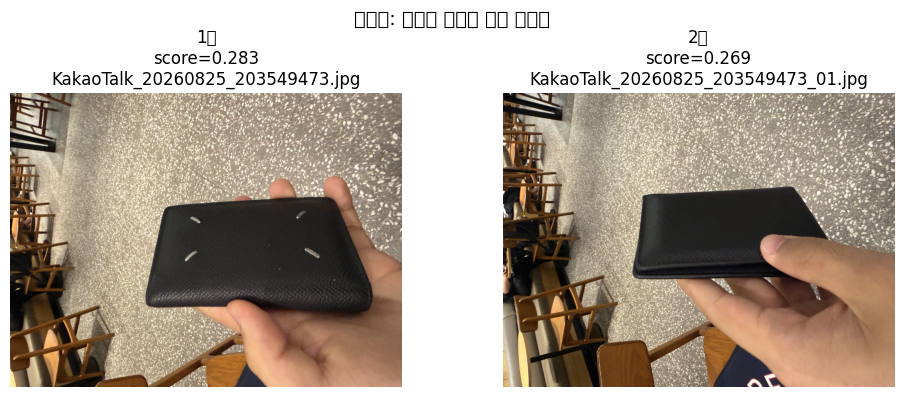

In [ ]:
def show_text_search_results(query, top_k=3):
    results = search_by_text(
        query,
        image_embeddings,
        image_paths,
        top_k=min(top_k, len(image_paths))
    )

    if not results:
        print("결과 없음")
        return

    plt.figure(figsize=(5 * len(results), 4))

    for i, result in enumerate(results):
        img = Image.open(result["image"]).convert("RGB")

        plt.subplot(1, len(results), i + 1)
        plt.imshow(img)
        plt.title(
            f"{i+1}위\n"
            f"score={result['score']:.3f}\n"
            f"{result['image']}"
        )
        plt.axis("off")

    plt.suptitle(f"검색어: {query}", fontsize=14)
    plt.tight_layout()
    plt.show()

show_text_search_results(
    "검은색 에어팟 프로 케이스",
    top_k=3
)

## STEP 15. 사진 + 글 점수 결합

MVP에서는 예를 들어:

```text
최종 점수 =
0.7 × image-image score
+
0.3 × text-image score
```

처럼 합쳐볼 수 있습니다.

단, `0.7 / 0.3`은 정답이 아니며 나중에 실제 데이터로 조정해야 합니다.

In [ ]:
def search_by_image_and_text(
    query_image_path,
    query_text,
    database_embeddings,
    database_paths,
    image_weight=0.7,
    text_weight=0.3,
    top_k=5
):
    # Image query embedding
    query_image_embedding = model.encode_image(
        [query_image_path],
        batch_size=1,
        normalize_embeddings=True,
        truncate_dim=EMBED_DIM
    )
    query_image_embedding = np.asarray(
        query_image_embedding,
        dtype=np.float32
    )[0]

    # Text query embedding
    query_text_embedding = model.encode_text(
        [query_text],
        task="retrieval.query",
        normalize_embeddings=True,
        truncate_dim=EMBED_DIM
    )
    query_text_embedding = np.asarray(
        query_text_embedding,
        dtype=np.float32
    )[0]

    # Similarity
    image_scores = database_embeddings @ query_image_embedding
    text_scores = database_embeddings @ query_text_embedding

    # Weighted score
    final_scores = (
        image_weight * image_scores
        + text_weight * text_scores
    )

    ranking = np.argsort(final_scores)[::-1][:top_k]

    results = []

    for idx in ranking:
        results.append({
            "index": int(idx),
            "image": database_paths[idx],
            "image_score": float(image_scores[idx]),
            "text_score": float(text_scores[idx]),
            "final_score": float(final_scores[idx])
        })

    return results

In [ ]:
query_image = image_paths[0]
query_text = "검은색 에어팟 프로 케이스"

results = search_by_image_and_text(
    query_image,
    query_text,
    image_embeddings,
    image_paths,
    image_weight=0.7,
    text_weight=0.3,
    top_k=min(5, len(image_paths))
)

print("Query image:", query_image)
print("Query text:", query_text)
print()

for rank, result in enumerate(results, start=1):
    print(
        f"{rank}위 | {result['image']} | "
        f"image={result['image_score']:.4f} | "
        f"text={result['text_score']:.4f} | "
        f"final={result['final_score']:.4f}"
    )

Query image: KakaoTalk_20260825_203549473.jpg
Query text: 검은색 에어팟 프로 케이스

1위 | KakaoTalk_20260825_203549473.jpg | image=1.0000 | text=0.2832 | final=0.7850
2위 | KakaoTalk_20260825_203549473_01.jpg | image=0.9364 | text=0.2689 | final=0.7361


## STEP 16. Embedding 저장

실제 서비스에서는 DB의 사진을 검색 때마다 다시 Jina CLIP에 넣지 않습니다.

습득물 등록 시:

```text
사진 → Jina CLIP → embedding → DB 저장
```

을 한 번만 수행합니다.

지금은 DB 대신 `.npy` 파일로 저장합니다.

In [ ]:
np.save("found_item_embeddings.npy", image_embeddings)

with open("found_item_paths.txt", "w", encoding="utf-8") as f:
    for path in image_paths:
        f.write(path + "\n")

print("✅ 저장 완료")
print("- found_item_embeddings.npy")
print("- found_item_paths.txt")

✅ 저장 완료
- found_item_embeddings.npy
- found_item_paths.txt


## STEP 17. 저장한 Embedding 다시 불러오기

In [ ]:
loaded_embeddings = np.load("found_item_embeddings.npy")

with open("found_item_paths.txt", "r", encoding="utf-8") as f:
    loaded_paths = [
        line.strip()
        for line in f
        if line.strip()
    ]

print("embedding shape:", loaded_embeddings.shape)
print("paths:", loaded_paths)

embedding shape: (2, 512)
paths: ['KakaoTalk_20260825_203549473.jpg', 'KakaoTalk_20260825_203549473_01.jpg']


# 실제 KU Finder에 붙일 때

최종적으로는 다음 구조로 가면 됩니다.

```text
[습득물 등록]
사진 + 설명 + 카테고리 + 장소
        │
        ├─ 사진 → Jina CLIP → image embedding
        │
        └─ DB 저장
                   ↓
            PostgreSQL + pgvector


[분실물 검색]
사진 + 설명
     │
     ├─ image embedding
     └─ text embedding
             │
             ↓
       similarity search
             │
             ↓
           Top-K
             │
             ↓
       후보 목록 반환
```

그 다음 단계:
1. FastAPI
2. PostgreSQL + pgvector
3. 카테고리 / 날짜 / 위치 필터
4. Top-K reranking

# 최종 체크리스트

- [ ] Colab T4 GPU가 잡힌다.
- [ ] Jina CLIP v2가 GPU에 로딩된다.
- [ ] 여러 사진이 `(N, 512)` embedding으로 변환된다.
- [ ] 사진 ↔ 사진 similarity가 출력된다.
- [ ] 한국어 글 ↔ 사진 similarity가 출력된다.
- [ ] Top-K 검색이 된다.
- [ ] 사진 + 글 점수를 결합할 수 있다.
- [ ] embedding을 저장하고 불러올 수 있다.

여기까지 되면 KU Finder의 **VLM Retrieval 1차 MVP**는 성공입니다.